# Préparation

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

## CLASSIFICATION

In [2]:
df = pd.read_csv("../data/processed/gdelt_benin_clean.csv")

features = [
    'GoldsteinNorm',
    'ToneNorm',
    'NumMentions',
    'NumArticles',
    'MediaWeight'
]

X = df[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



## PCA

In [3]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

print(pca.explained_variance_ratio_)

[0.37934256 0.31115678]


## K-Means

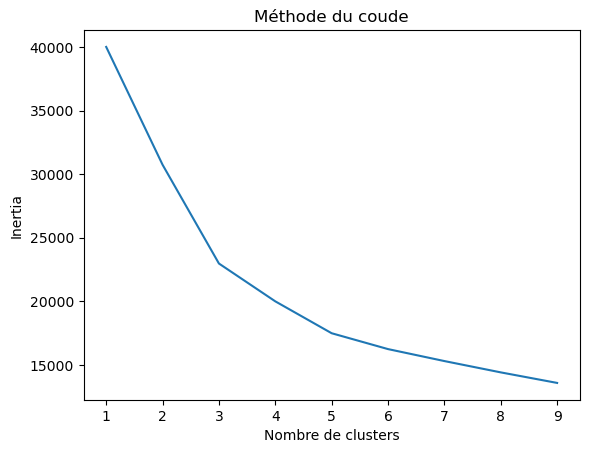

In [4]:

inertia = []
K = range(1,10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K, inertia)
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertia")
plt.title("Méthode du coude")
plt.show()

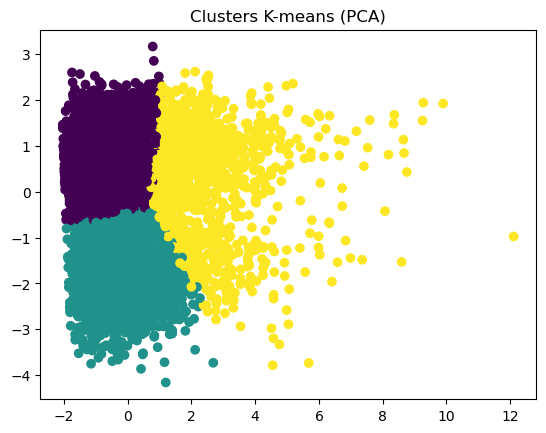

In [5]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['cluster_kmeans'] = clusters

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.title("Clusters K-means (PCA)")
plt.show()

## DBSCAN

In [6]:


dbscan = DBSCAN(eps=0.5, min_samples=5)
db_clusters = dbscan.fit_predict(X_scaled)

df['cluster_dbscan'] = db_clusters



In [7]:
df.groupby('cluster_kmeans')[features].mean()

,GoldsteinNorm,ToneNorm,NumMentions,NumArticles,MediaWeight
cluster_kmeans,,,,,
0,0.604653,0.546844,6.798646,3.156659,19.367269
1,0.318991,0.390730,7.253327,3.515209,23.429183
2,0.538182,0.516251,12.538881,7.343793,81.938608


# PREDICTION

In [8]:
y = df['IsConflict']

In [9]:
features = [
    'GoldsteinNorm',
    'ToneNorm',
    'NumMentions',
    'NumArticles',
    'MediaWeight',
    'IsNorthBenin'
]

X = df[features].fillna(0)

In [10]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## RANDOM FOREST

In [11]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.97      0.97      1123
           1       0.93      0.91      0.92       477

    accuracy                           0.95      1600
   macro avg       0.94      0.94      0.94      1600
weighted avg       0.95      0.95      0.95      1600



## XGBOOST

In [12]:


model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1123
           1       0.93      0.89      0.91       477

    accuracy                           0.95      1600
   macro avg       0.94      0.93      0.94      1600
weighted avg       0.95      0.95      0.95      1600



c:\Users\TSS\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:38:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


<Axes: >

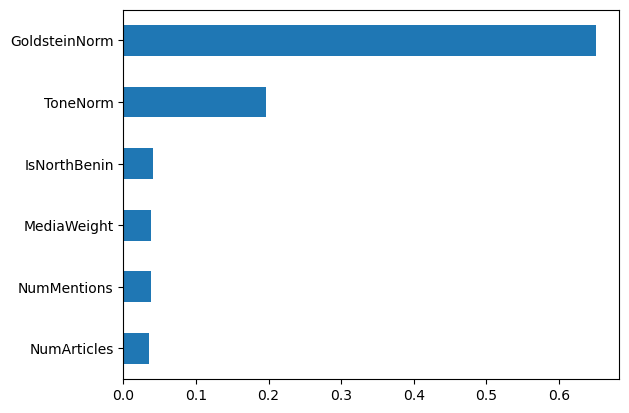

In [13]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')



In [14]:
df['proba_conflict'] = model.predict_proba(X)[:,1]

Steamlit

In [ ]:
st.write("Clusters")
st.scatter_chart(df[['PC1','PC2']])

st.write("Probabilité de conflit")
st.dataframe(df[['Actor1Name','proba_conflict']])